<a href="https://colab.research.google.com/github/Sechavez16/MachineLearning-IA/blob/main/U4_Prediccion_Desercion_Estudiantil.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 **Contexto del problema (para el informe)**

**Título del proyecto:**
Predicción del Estado Académico de Estudiantes Universitarios (Graduado, Enrollado o Desertor)

**Problema a resolver:** La deserción estudiantil es un problema crítico en la educación superior, con consecuencias sociales y económicas significativas. Identificar tempranamente a los estudiantes en riesgo de desertar permite implementar intervenciones oportunas para mejorar la retención.

**Tipo de problema: **Aprendizaje supervisado - Clasificación multiclase (3 clases: Graduate, Enrolled, Dropout)

**Contexto de las variables de categoria**
* **Graduate (Graduado)**
Significado: El estudiante completó con éxito el programa académico y obtuvo su título.
Contexto: Representa el resultado exitoso del proceso educativo.

* **Dropout (Desertor / Abandono)**
Significado: El estudiante abandonó sus estudios antes de completar el programa.
Contexto: Es el problema central que el dataset busca predecir. La institución quiere identificar a estos estudiantes para prevenir el abandono.

* **Enrolled (Matriculado / En curso)**
Significado: El estudiante aún está cursando la carrera y no ha terminado ni abandonado.
Contexto: Son estudiantes activos que no han llegado al punto de graduarse o desertar al momento de la toma de datos.

**Contexto adicional del dataset (de la página de Kaggle)**
* **Link:** https://www.kaggle.com/datasets/thedevastator/higher-education-predictors-of-student-retention/data
* **Origen:** Datos de estudiantes de una institución de educación superior (no especificada, pero por el contexto se asume es portuguesa).

* **Objetivo:** Investigar el impacto de factores sociales, económicos y académicos en la deserción y el éxito académico.

* **Variables:** Incluye datos demográficos (edad, género, nacionalidad), socioeconómicos (beca, ocupación de padres), académicos (calificaciones, unidades curriculares) y macroeconómicos (tasa de desempleo, inflación, PIB).

In [ ]:
"""
============================================================
PASO 1: IMPORTAR LIBRERÍAS BASE
============================================================
pandas: Manipulación de datos tabulares (permite cargar el dataset, ver columnas, filtrar datos, agrupar informacion)
numpy: Operaciones matemáticas (permite hacer calculos estadisticos, transformar datos numericos)
matplotlib: Visualización de datos (Para graficar distribuciones, comparar resultados, visualizar datos)
seaborn: Visualización estadística avanzada (Para hacer gráficos más bonitos y complejos como mapas de calor, boxplots, distribuciones)
============================================================
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print(" Librerías base cargadas correctamente")

In [ ]:
"""
============================================================
PASO 1.2: LIBRERÍAS DE MACHINE LEARNING
============================================================
train_test_split: Dividir datos en entrenamiento y prueba (separa el dataset en dos partes: una para entrenar el modelo y otra para probarlo)
LabelEncoder: Convertir texto a números (convierte categorías en texto como "Graduate", "Dropout", "Enrolled" a números 0, 1, 2 porque los algoritmos solo entienden números)
StandardScaler: Normalizar datos numéricos (escala los datos para que tengan media 0 y desviación 1, evitando que variables con escalas muy diferentes dominen el modelo)
LogisticRegression: Algoritmo de clasificación base (calcula la probabilidad de que un dato pertenezca a una categoría, es sencillo e interpretable)
DecisionTreeClassifier: Árboles de decisión (crea un árbol de decisiones donde cada nodo pregunta por una característica para clasificar, es fácil de interpretar)
RandomForestClassifier: Bosque aleatorio (crea muchos árboles de decisión y combina sus predicciones, es más robusto que un solo árbol)
accuracy_score: Calcular precisión (calcula el porcentaje de predicciones correctas del modelo)
classification_report: Reporte detallado (muestra Precisión, Recall y F1-Score para cada categoría)
confusion_matrix: Matriz de confusión (muestra cuántas veces el modelo clasificó correctamente y cuántas veces se equivocó por categoría)
============================================================
"""

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print(" Librerías de Machine Learning cargadas correctamente")

 Librerías de Machine Learning cargadas correctamente


In [ ]:
"""
============================================================
PASO 2: CARGAR EL DATASET
============================================================
Dataset: Predict students' dropout and academic success
Fuente: Kaggle (enlace directo)
============================================================
"""
url = "https://www.kaggle.com/api/v1/datasets/thedevastator/higher-education-predictors-of-student-retention/download?format=csv"
df = pd.read_csv(url)

print(f"✅ Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")

In [ ]:
"""
============================================================
PASE 3: CARGAR EK ARCHIVO DATASET
============================================================
Como estamso en colab, el dataset se subio a la cuenta de google drive, se le puso compartir y la opcion de cualquier persona con el link y el acceso es de tipo lector
Para importar el dataset se usara gdown,
"""
import gdown

# 1. Descargar desde Drive
url = "https://drive.google.com/file/d/1OYFrh5GeCTmD4hOQ7JSNdoftyHl1_LYz/view?usp=sharing"
#Necesitamos el ID del archivo paar poder descargar el archivo de drive en este caso el ID es 1OYFrh5GeCTmD4hOQ7JSNdoftyHl1_LYz y se encuentra en el link
file_id = url.split('/d/')[1].split('/view')[0]
gdown.download(f"https://drive.google.com/uc?id={file_id}", "dataset.csv", quiet=False)

# 2. Cargar en DataFrame
df = pd.read_csv("dataset.csv")
#verificamso que cargamos el datset, por tal razon imprimimos el numero de filas y el numero de columnas
print("\n")
print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")

Downloading...
From: https://drive.google.com/uc?id=1OYFrh5GeCTmD4hOQ7JSNdoftyHl1_LYz
To: /content/dataset.csv
100%|██████████| 471k/471k [00:00<00:00, 120MB/s]



Dataset cargado: 4424 filas, 35 columnas


In [ ]:
#Imprimimos la primera 10 filas del datset para teenr idea
df.head(10)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
5,2,12,1,17,0,12,1,22,27,10,...,0,5,17,5,11.500000,5,16.2,0.3,-0.92,Graduate
6,1,1,1,12,1,1,1,13,28,8,...,0,8,8,8,14.345000,0,15.5,2.8,-4.06,Graduate
7,1,9,4,11,1,1,1,22,27,10,...,0,5,5,0,0.000000,0,15.5,2.8,-4.06,Dropout
8,1,1,3,10,1,1,15,1,1,10,...,0,6,7,6,14.142857,0,16.2,0.3,-0.92,Graduate
9,1,1,1,10,1,1,1,1,14,5,...,0,6,14,2,13.500000,0,8.9,1.4,3.51,Dropout


In [ ]:
#Observamos que la variable Y para categorizar va ser la columna target
#Usamos pandas para ver los tipos de datos, valores nulos y memoria del dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                      

**Análisis de la estructura del dataset mediante el info() de pandas**

El dataset cargado, denominado "Predict students' dropout and academic success", está compuesto por un total de 4,424 registros, donde cada fila representa a un estudiante. La estructura del mismo se compone de 35 columnas o variables, las cuales incluyen información demográfica, socioeconómica, de rendimiento académico y contexto macroeconómico.

En cuanto a la calidad de los datos, se realizó una verificación inicial mediante el método df.info(), que reveló que no existen valores nulos en ninguna de las variables, ya que todas las columnas cuentan con 4,424 valores no nulos. Esto indica que el dataset se encuentra completo y no requiere procesos de imputación o eliminación de datos faltantes, lo cual facilita las etapas posteriores de preprocesamiento.

Respecto a los tipos de datos, se identificó que 29 variables son de tipo entero (int64) , lo que sugiere que contienen valores numéricos discretos, como conteos o códigos categóricos. Por otro lado, 5 variables son de tipo flotante (float64) , lo que indica que almacenan valores numéricos continuos, como calificaciones promedio o indicadores económicos. Finalmente, solo una variable es de tipo objeto (object) , la cual corresponde a la columna Target. Esta variable, que representa el estado académico del estudiante, contiene valores de texto y será la variable objetivo a predecir en el modelo de clasificación.

La ausencia de valores nulos y la claridad en los tipos de datos permiten avanzar de manera eficiente hacia las fases de análisis exploratorio y preparación de datos para el modelo de aprendizaje automático.

In [ ]:
"""
============================================================
PASO 2.2 CONTEO DE CATEGOERIAS EN L AVARIABLE TARGET
============================================================
Objetivo: Verificar cuantos estudaintes hay en cada estado academico
"""
#Nos vamos el datset que esta en df y de ahi vamos a la colmuna target, y hacemos un conteo por categoria
conteo = df['Target'].value_counts()
print(f"Numero de estudiantes por estado: {conteo} \n")

Numero de estudiantes por estado: Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64 



**Análisis de la variable target**

La variable objetivo Target presenta tres categorías que representan el estado académico final del estudiante: Graduate (graduado), Dropout (desertor) y Enrolled (matriculado/en curso). El análisis de frecuencia muestra la siguiente distribución:

Graduate: 2,209 estudiantes, lo que representa el 49.93% del total.

Dropout: 1,421 estudiantes, lo que representa el 32.12% del total.

Enrolled: 794 estudiantes, lo que representa el 17.95% del total.

**Definicion del problema**

El objetivo es desarrollar un modelo de aprendizaje automático que, a partir de datos demográficos, socioeconómicos y de rendimiento académico, pueda predecir el estado académico final de un estudiante al término de su trayectoria, clasificándolo en una de tres categorías:

* Graduate: estudiante que completa y aprueba el programa de estudios.

* Dropout: estudiante que abandona el programa antes de finalizarlo.

* Enrolled: estudiante que continúa matriculado después de la duración normal del programa.

Este problema es de clasificación supervisada, ya que se dispone de un conjunto de datos etiquetados con el estado real de los estudiantes, y se busca aprender un modelo que pueda predecir dicho estado para nuevos casos.

In [ ]:
"""
============================================================
Paso 3.0: SELECCION DE LAS VARIABLES REPRESENTATIVAS
============================================================
Objetivo: Elegir las columnas más relevantes para el modelo y jusrificar
"""
# Variables que usaremos como características (X)
# Basado en la literatura, estas son predictoras clave de deserción
columnas_seleccionadas = [
    'Age at enrollment',           # Edad al matricularse
    'Scholarship holder',          # Becario (1=Sí, 0=No)
    'Debtor',                      # Deudor (1=Sí, 0=No)
    'Tuition fees up to date',     # Matrícula al día (1=Sí, 0=No)
    'Gender',                      # Género (1=Hombre, 0=Mujer)
    'Curricular units 1st sem (approved)',  # Unidades aprobadas 1er sem
    'Curricular units 1st sem (grade)',     # Calificación promedio 1er sem
    'Curricular units 2nd sem (approved)',  # Unidades aprobadas 2do sem
    'Curricular units 2nd sem (grade)',     # Calificación promedio 2do sem
    'Unemployment rate',           # Tasa de desempleo
    'GDP'                          # Producto Interno Bruto
]

#Creamos las caracteristicas del modelo X, y Y que es la variable objetivo
X = df[columnas_seleccionadas]
y = df['Target'] #Variable objetivo (Object: Graduate, Dropout, Enroller)

#Imprimimos el numwro de variables seleccionadas
#Las caractaristcias que son las columans del dataset
#Y variables objetivos
print(f"Numero de variables selccionadas: {len(columnas_seleccionadas)}")
print(f"Caracteristicas X: {X.shape[1]} columnas")
print(f"Variable objetivo y : {y.name} \n")

Numero de variables selccionadas: 11
Caracteristicas X: 11 columnas
Variable objetivo y : Target 



In [ ]:
"""
============================================================
PASO 3.1: PREPARACIÓN DE DATOS (CODIFICAR, DIVIDIR, ESCALAR)
============================================================
Objetivo: Preparar los datos para el entrenamiento del modelo
1. Codificar la variable Target (texto → números)
2. Dividir en entrenamiento (70%) y prueba (30%)
3. Escalar los datos numéricos (StandardScaler)
============================================================
"""
#
#Para codificar creamos el codificador
le = LabelEncoder()
#Codificamos la varaible Target para pasar de Texto a Numero
y_encoded = le.fit_transform(y)
# Ver el mapeo completo
print("📋 Mapeo de categorías a números:")
for i, categoria in enumerate(le.classes_):
    print(f"   {categoria} → {i}")

📋 Mapeo de categorías a números:
   Dropout → 0
   Enrolled → 1
   Graduate → 2


Observamos que le.clases guadardo de froma alfabetica las categorias de target, y el casteo de String a numero quedo como:

* Dropout → 0
* Enrolled → 1
* Graduate → 2

In [ ]:
"""
============================================================
PASO 3.2: DIVIDIR Y ESCALAR LOS DATOS
============================================================
Objetivo: Completar la preparación de datos
1. Dividir en entrenamiento (70%) y prueba (30%)
2. Escalar los datos numéricos (StandardScaler)
============================================================
"""
#dividimos los datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,            # le pasamos la caracteristicas X y Y codificado
    test_size=0.3,           # 30% para prueba
    random_state=42,         # Semilla para reproducibilidad
    stratify=y_encoded       # Mantiene la proporción de clases
)
print("cuantos en entrenameinto y cuantos en prueba")
print(f"Entrenamiento: {len(X_train)} muestras ({len(X_train)/len(X)*100:.1f}%)")
print(f"Prueba: {len(X_test)} muestras ({len(X_test)/len(X)*100:.1f}%)")

cuantos en entrenameinto y cuantos en prueba
Entrenamiento: 3096 muestras (70.0%)
Prueba: 1328 muestras (30.0%)


In [ ]:
#Escalamos los datos de entrenamiento
# Escalar los datos de entrenamiento (fit + transform)
#Para escalar los datos usamos StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Escalar los datos de prueba (solo transform, con la misma escala de entrenamiento)
X_test_scaled = scaler.transform(X_test)


(3096, 11)
(1328, 11)


In [ ]:
"""
============================================================
PASO 3.3: ENTRENAMIENTO - REGRESIÓN LOGÍSTICA
============================================================
Objetivo: Entrenar modelo base de regresión logística
============================================================
"""
# Creamos y entrenamos el modelo
modelo_lr = LogisticRegression(
    max_iter=1000,              # Aumentamos iteraciones para garantizar convergencia
    random_state=42,            # Fijamos semilla de reproducibilidad
    multi_class='multinomial',  # ¡Corregido! Para clasificación multiclase (3 categorías)
    solver='lbfgs'              # Algoritmo de optimización adecuado para multiclase
)

print("="*60)
print("REGRESIÓN LOGÍSTICA - ENTRENAMIENTO")


# Entrenamos el modelo
print(" Entrenando modelo...")
modelo_lr.fit(X_train_scaled, y_train)
print(" Modelo entrenado correctamente")

# Hacemos predicciones (¡Corregido: punto en lugar de guión!)
y_pred_lr = modelo_lr.predict(X_test_scaled)

# Evaluamos el modelo (¡Corregido: accuracy_score bien escrito!)
accuracy_lr = accuracy_score(y_test, y_pred_lr)


print(" REGRESIÓN LOGÍSTICA - RESULTADOS")
print(f" Accuracy (Precisión): {accuracy_lr:.4f}")  # ¡Corregido: formato .4f!

print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

print(" Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_lr))

REGRESIÓN LOGÍSTICA - ENTRENAMIENTO
 Entrenando modelo...
 Modelo entrenado correctamente
 REGRESIÓN LOGÍSTICA - RESULTADOS
 Accuracy (Precisión): 0.7342
Reporte de clasificación:
              precision    recall  f1-score   support

     Dropout       0.76      0.73      0.74       427
    Enrolled       0.48      0.18      0.26       238
    Graduate       0.75      0.94      0.83       663

    accuracy                           0.73      1328
   macro avg       0.66      0.61      0.61      1328
weighted avg       0.70      0.73      0.70      1328

 Matriz de confusión:
[[311  38  78]
 [ 64  42 132]
 [ 33   8 622]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


# RESULTADOS DEL MODELO DE REGRESIÓN LOGÍSTICA

## Resumen del rendimiento

El modelo de Regresión Logística alcanzó una **precisión global (Accuracy) del 73.42%** en el conjunto de prueba, lo que significa que clasificó correctamente a 975 de los 1,328 estudiantes evaluados.

## Análisis por categoría

| Categoría | Precisión | Recall (Sensibilidad) | F1-Score | Soporte (casos reales) |
|---|---|---|---|---|
| **Dropout** (Desertor) | 0.76 | 0.73 | 0.74 | 427 |
| **Enrolled** (Matriculado) | 0.48 | 0.18 | 0.26 | 238 |
| **Graduate** (Graduado) | 0.75 | 0.94 | 0.83 | 663 |

### Interpretación de las métricas

*   **Precisión (Precision):** Mide la exactitud de las predicciones positivas. Ejemplo: de todos los estudiantes que el modelo predijo como "Dropout", el 76% realmente lo eran.
*   **Recall (Sensibilidad):** Mide la capacidad del modelo para detectar a los estudiantes de una clase específica. Ejemplo: de todos los estudiantes que realmente eran "Graduate", el modelo detectó correctamente al 94%.
*   **F1-Score:** Es la media armónica entre precisión y recall, que equilibra ambas métricas. Un valor alto indica un buen rendimiento general en esa categoría.

### Análisis de rendimiento por clase

*   **Graduate (Graduado):** Es la clase mejor clasificada, con un recall del 94%. Esto indica que el modelo identifica muy bien a los estudiantes que se gradúan.
*   **Dropout (Desertor):** Tiene un rendimiento aceptable, con un recall del 73% y una precisión del 76%. El modelo detecta bien a los desertores, aunque puede mejorar.
*   **Enrolled (Matriculado):** Es la clase con peor rendimiento. El modelo solo detecta al 18% de los estudiantes en esta categoría (recall bajo). Esto se debe a que es la clase minoritaria y a menudo se confunde con "Graduate".

## Matriz de confusión

La matriz de confusión muestra los aciertos y errores del modelo:


In [ ]:

"""
============================================================
PASO 3.4: ENTRENAMIENTO - ÁRBOL DE DECISIÓN
============================================================
Objetivo: Entrenar modelo de árbol de decisión para clasificación multiclase
============================================================

ÁRBOL DE DECISIÓN:
- Es un modelo que toma decisiones dividiendo los datos en ramas basadas en preguntas sobre las características.
- Es muy interpretable, ya que se puede visualizar como un diagrama de flujo.
- Puede capturar relaciones no lineales entre las variables y la variable objetivo.

PARÁMETROS:
- max_depth=5: Profundidad máxima del árbol. Limitar la profundidad ayuda a prevenir el sobreajuste.
- random_state=42: Semilla para reproducibilidad.
- criterion='gini': Medida de calidad de la división (por defecto 'gini').
- splitter='best': Estrategia para elegir la división (por defecto 'best').
"""
modelo_dt = DecisionTreeClassifier(
    max_depth=5,        # Limitamos la profundidad para evitar sobreajuste
    random_state=42,    # Fijamos semilla para reproducibilidad
    criterion='gini',   # Medida de impureza para las divisiones
    splitter='best'     # Estrategia para elegir la división
)
print("Arbol de decision - Entrenar")
# Entrenar el modelo (con los datos escalados, aunque no es necesario para árboles, lo usamos para consistencia)
print("Entrenando modelo...")
modelo_dt.fit(X_train_scaled, y_train)
print("Modelo entrenado correctamente")
# Hacer predicciones sobre el conjunto de prueba
y_pred_dt = modelo_dt.predict(X_test_scaled)

# Evaluar el modelo
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(" ÁRBOL DE DECISIÓN - RESULTADOS")
print(f" Accuracy (Precisión): {accuracy_dt:.4f}")

print(" Reporte de clasificación:")
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_dt))


Arbol de decision - Entrenar
Entrenando modelo...
Modelo entrenado correctamente
 ÁRBOL DE DECISIÓN - RESULTADOS
 Accuracy (Precisión): 0.7515
 Reporte de clasificación:
              precision    recall  f1-score   support

     Dropout       0.81      0.70      0.75       427
    Enrolled       0.56      0.30      0.39       238
    Graduate       0.76      0.95      0.84       663

    accuracy                           0.75      1328
   macro avg       0.71      0.65      0.66      1328
weighted avg       0.74      0.75      0.73      1328

Matriz de confusión:
[[298  49  80]
 [ 44  72 122]
 [ 27   8 628]]


# RESULTADOS DEL MODELO DE ÁRBOL DE DECISIÓN

## Resumen del rendimiento

El modelo de Árbol de Decisión alcanzó una precision global (Accuracy) del 75.15% en el conjunto de prueba, lo que significa que clasifico correctamente a 998 de los 1,328 estudiantes evaluados. Este resultado es ligeramente superior al obtenido con Regresion Logistica (73.42%).

## Analisis por categoria

| Categoria | Precision | Recall (Sensibilidad) | F1-Score | Soporte (casos reales) |
|---|---|---|---|---|
| Dropout (Desertor) | 0.81 | 0.70 | 0.75 | 427 |
| Enrolled (Matriculado) | 0.56 | 0.30 | 0.39 | 238 |
| Graduate (Graduado) | 0.76 | 0.95 | 0.84 | 663 |

### Interpretacion de las metricas

*   Precision: Mide la exactitud de las predicciones positivas. Ejemplo: de todos los estudiantes que el modelo predijo como "Dropout", el 81% realmente lo eran.
*   Recall (Sensibilidad): Mide la capacidad del modelo para detectar a los estudiantes de una clase especifica. Ejemplo: de todos los estudiantes que realmente eran "Graduate", el modelo detecto correctamente al 95%.
*   F1-Score: Es la media armonica entre precision y recall, que equilibra ambas metricas. Un valor alto indica un buen rendimiento general en esa categoria.

### Analisis de rendimiento por clase

*   Graduate (Graduado): Es la clase mejor clasificada, con un recall del 95%. El modelo identifica excelentemente a los estudiantes que se gradúan.
*   Dropout (Desertor): Tiene un rendimiento bueno, con un recall del 70% y una precision del 81%. El modelo detecta bien a los desertores.
*   Enrolled (Matriculado): Sigue siendo la clase con peor rendimiento, aunque mejoro ligeramente respecto a Regresion Logistica. El recall aumento del 18% al 30%, lo que indica que el modelo ahora detecta a mas estudiantes en esta categoria.

## Matriz de confusion

La matriz de confusion muestra los aciertos y errores del modelo:


In [ ]:
"""
============================================================
PASO 3.5: ENTRENAMIENTO - RANDOM FOREST
============================================================
Objetivo: Entrenar modelo de bosque aleatorio para clasificación multiclase
============================================================

RANDOM FOREST:
- Es un conjunto (ensemble) de múltiples árboles de decisión.
- Cada árbol se entrena con una muestra aleatoria de los datos (bootstrap) y características.
- La predicción final se obtiene por votación (mayoría) de todos los árboles.
- Es más robusto que un solo árbol y reduce el sobreajuste.

PARÁMETROS:
- n_estimators=100: Número de árboles en el bosque.
- random_state=42: Semilla para reproducibilidad.
- max_depth=10: Profundidad máxima de cada árbol (limitada para evitar sobreajuste).
- min_samples_split=5: Número mínimo de muestras para dividir un nodo.
- n_jobs=-1: Usa todos los núcleos del procesador para entrenar más rápido.
"""
# Crear y entrenar el modelo
modelo_rf = RandomForestClassifier(
    n_estimators=100,        # Número de árboles en el bosque
    random_state=42,         # Semilla para reproducibilidad
    max_depth=10,            # Profundidad máxima de cada árbol
    min_samples_split=5,     # Mínimo de muestras para dividir un nodo
    n_jobs=-1                # Usar todos los núcleos disponibles
)

#entrenamos el modelo
print(" Random Forest - Entrenamiento")
print("Entrenando modelo...")
modelo_rf.fit(X_train_scaled, y_train)

print("Modelo entrenado correctamente")
# Hacer predicciones sobre el conjunto de prueba
y_pred_rf = modelo_rf.predict(X_test_scaled)

# Evaluar el modelo
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy (Precisión): {accuracy_rf:.4f}")

print(" Reporte de clasificación:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

print(" Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_rf))

 Random Forest - Entrenamiento
Entrenando modelo...
Modelo entrenado correctamente
Accuracy (Precisión): 0.7636
 Reporte de clasificación:
              precision    recall  f1-score   support

     Dropout       0.78      0.75      0.77       427
    Enrolled       0.57      0.29      0.38       238
    Graduate       0.78      0.94      0.85       663

    accuracy                           0.76      1328
   macro avg       0.71      0.66      0.67      1328
weighted avg       0.74      0.76      0.74      1328

 Matriz de confusión:
[[320  37  70]
 [ 65  69 104]
 [ 23  15 625]]



*   Aciertos (diagonal principal): 320 + 69 + 625 = 1,014 aciertos.
*   Errores más comunes:
    *   104 estudiantes "Enrolled" fueron clasificados erróneamente como "Graduate".
    *   70 estudiantes "Dropout" fueron clasificados erróneamente como "Graduate".

## Comparación de los tres modelos

| Modelo | Accuracy | Mejora respecto al anterior |
|---|---|---|
| Regresión Logística | 73.42% | - |
| Árbol de Decisión | 75.15% | +1.73% |
| Random Forest | 76.36% | +1.21% |

El modelo Random Forest mejora la precisión global en un 1.21% respecto al Árbol de Decisión y en un 2.94% respecto a la Regresión Logística. La mejora más notable se da en la detección de la clase "Dropout", cuyo recall aumentó de 0.70 (Árbol de Decisión) a 0.75 (Random Forest).

## Conclusión del modelo

El modelo de Random Forest ofrece el mejor rendimiento de los tres algoritmos evaluados. Su capacidad para combinar múltiples árboles de decisión y capturar relaciones complejas entre las variables y la variable objetivo lo convierte en el modelo más adecuado para este problema de clasificación. La clase "Enrolled" sigue siendo la más difícil de predecir, lo que sugiere que se necesitarían más datos o características adicionales para mejorar su detección.

---

In [ ]:
"""
============================================================
PASO 4: COMPARACIÓN Y ANÁLISIS CRÍTICO DE MODELOS
============================================================
Objetivo: Comparar el rendimiento de los tres modelos y analizar sus limitaciones
============================================================
"""
#Creamos un dataFrame con los accury de cada modelo para hacer un versus
resultados = {
    'Modelo': ['Regresión Logística', 'Árbol de Decisión', 'Random Forest'],
    'Accuracy': [0.7342, 0.7515, 0.7636]
}
#se gaudar en df_resulatdo usando pandas
df_resultados = pd.DataFrame(resultados)
print(df_resultados)

                Modelo  Accuracy
0  Regresión Logística    0.7342
1    Árbol de Decisión    0.7515
2        Random Forest    0.7636


/tmp/ipykernel_1529/1104193325.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


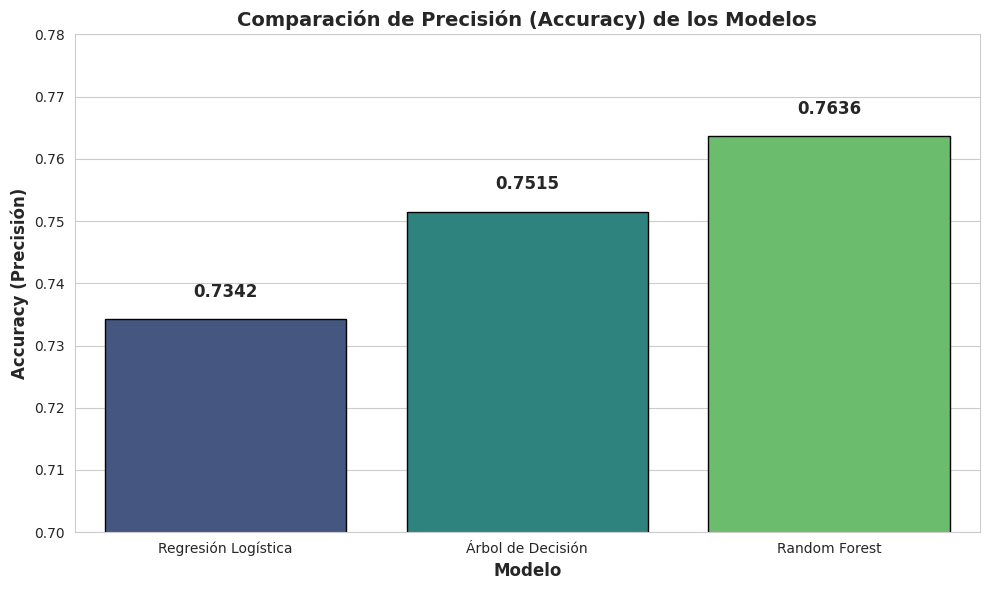


✅ Gráfico generado correctamente


In [ ]:
"""
============================================================
PASO 4.1: VISUALIZACIÓN DE LA COMPARACIÓN DE MODELOS
============================================================
Objetivo: Crear un gráfico de barras para comparar los tres modelos
============================================================

CONFIGURACIÓN DEL GRÁFICO:
- figure(figsize=(10, 6)): Tamaño de la figura (ancho 10, alto 6 pulgadas)
- sns.barplot: Crea un gráfico de barras con seaborn
- palette='viridis': Paleta de colores (azul-verde-amarillo)
- title: Título del gráfico
- xlabel/ylabel: Etiquetas de los ejes
- ylim: Límite del eje Y (para enfocar la comparación)
- text: Agrega los valores encima de las barras
- show: Muestra el gráfico
"""
# Configurar el estilo de los gráficos
sns.set_style("whitegrid")  # Fondo con cuadrícula blanca
plt.rcParams['figure.figsize'] = (10, 6)  # Tamaño estándar de gráficos

#creamos el grafico de barras

# Crear la figura y los ejes
plt.figure(figsize=(10, 6))

# Crear el gráfico de barras
# - x: Modelo, y: Accuracy, data: dataframe con los resultados
# - palette: Colores viridis (tonos de azul-verde)
# - edgecolor: Borde de las barras en negro para mejor contraste
barplot = sns.barplot(
    x='Modelo',
    y='Accuracy',
    data=df_resultados,
    palette='viridis',
    edgecolor='black',
    linewidth=1
)

# 2. PERSONALIZAR EL GRÁFICO
# Título del gráfico
plt.title('Comparación de Precisión (Accuracy) de los Modelos', fontsize=14, fontweight='bold')

# Etiquetas de los ejes
plt.xlabel('Modelo', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy (Precisión)', fontsize=12, fontweight='bold')

# Ajustar el rango del eje Y para mejor visualización (0.70 a 0.78)
plt.ylim(0.70, 0.78)

# 3. AGREGAR LOS VALORES ENCIMA DE LAS BARRAS
# Recorremos cada barra y agregamos el valor numérico
for i, v in enumerate(df_resultados['Accuracy']):
    plt.text(
        i,                          # Posición en X (índice de la barra)
        v + 0.003,                  # Posición en Y (ligeramente arriba de la barra)
        f'{v:.4f}',                 # Texto con 4 decimales
        ha='center',                # Alineación horizontal centrada
        va='bottom',                # Alineación vertical abajo
        fontsize=12,                # Tamaño de la fuente
        fontweight='bold'           # Negrita para destacar
    )

# 4. MOSTRAR EL GRÁFICO
plt.tight_layout()  # Ajusta el diseño para que no se corten elementos
plt.show()          # Muestra el gráfico

print("\n✅ Gráfico generado correctamente")

In [ ]:
# ============================================================
# ACTIVIDAD: LIMPIEZA DEL CONJUNTO DE DATOS
# ============================================================
# Autor: Sebastián Echavez
#
# Este programa realiza las siguientes tareas:
# 1. Permite seleccionar un archivo CSV desde el computador.
# 2. Lee el conjunto de datos.
# 3. Limpia los nombres de las columnas.
# 4. Convierte la columna CANTIDAD a valores numéricos.
# 5. Elimina registros con datos nulos o no numéricos.
# 6. Guarda un nuevo archivo limpio.
# 7. Descarga automáticamente el archivo limpio.
# ============================================================

# ============================================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================================

# pandas permite leer, manipular y analizar datos.
import pandas as pd

# files permite subir y descargar archivos en Google Colab.
from google.colab import files

# ============================================================
# CARGAR EL ARCHIVO DESDE EL COMPUTADOR
# ============================================================

print("Seleccione el archivo CSV...")

uploaded = files.upload()

# Obtiene el nombre del archivo seleccionado
archivo = next(iter(uploaded))

# ============================================================
# LEER EL ARCHIVO
# ============================================================

df = pd.read_csv(
    archivo,
    sep=";",          # Separador utilizado en el archivo
    encoding="latin1" # Codificación del archivo
)

# ============================================================
# LIMPIEZA DE LOS NOMBRES DE LAS COLUMNAS
# ============================================================

# Elimina espacios antes y después del nombre de cada columna
df.columns = df.columns.str.strip()

print("\nColumnas encontradas:")
print(df.columns)

# ============================================================
# INFORMACIÓN ANTES DE LA LIMPIEZA
# ============================================================

print("\nNúmero de registros originales:", len(df))

# ============================================================
# LIMPIEZA DE LA COLUMNA CANTIDAD
# ============================================================

# Convierte la columna a tipo numérico.
# Los valores no numéricos se convierten en NaN.
df["CANTIDAD"] = pd.to_numeric(
    df["CANTIDAD"],
    errors="coerce"
)

# Cantidad de registros inválidos
registros_invalidos = df["CANTIDAD"].isna().sum()

print("\nRegistros con valores nulos o no numéricos:", registros_invalidos)

# Eliminar registros inválidos
df = df.dropna(subset=["CANTIDAD"])

# Convertir a números enteros
df["CANTIDAD"] = df["CANTIDAD"].astype(int)

# ============================================================
# INFORMACIÓN DESPUÉS DE LA LIMPIEZA
# ============================================================

print("\nPrimeras cinco filas del conjunto de datos limpio:")
print(df.head())

print("\nInformación general del DataFrame:")
print(df.info())

print("\nEstadísticas descriptivas de la variable CANTIDAD:")
print(df["CANTIDAD"].describe())

print("\nNúmero de registros después de la limpieza:", len(df))

# ============================================================
# GUARDAR EL ARCHIVO LIMPIO
# ============================================================

nombre_salida = "conjunto-de-datos-grupo-de-campo_limpio.csv"

df.to_csv(
    nombre_salida,
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

print("\nEl archivo limpio fue guardado correctamente como:")
print(nombre_salida)

# ============================================================
# DESCARGAR EL ARCHIVO
# ============================================================

files.download(nombre_salida)

print("\nProceso finalizado correctamente.")

Seleccione el archivo CSV...


Saving conjunto-de-datos-grupo-de-campo.csv to conjunto-de-datos-grupo-de-campo (1).csv

Columnas encontradas:
Index(['FECHA DE VISITA', 'MOTIVO DE VISITA', 'REMITIDO POR',
       'COMUNA/CORREGIMIENTO', 'BARRIO', 'TIPO DE ANIMAL', 'CANTIDAD'],
      dtype='object')

Número de registros originales: 907

Registros con valores nulos o no numéricos: 282

Primeras cinco filas del conjunto de datos limpio:
  FECHA DE VISITA MOTIVO DE VISITA       REMITIDO POR COMUNA/CORREGIMIENTO  \
0      25/01/2024         Denuncia         Inspección             Comuna 2   
1      30/01/2024         Denuncia         Inspección             Comuna 3   
2      30/01/2024   Acompañamiento  Policia Ambiental             Comuna 9   
3      31/01/2024         Denuncia         Inspección            Comuna 19   
5      01/02/2024         Denuncia         Inspección             Comuna 2   

                   BARRIO TIPO DE ANIMAL  CANTIDAD  
0            Villa Fatima        Caninos         2  
1              Santa

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Proceso finalizado correctamente.
